# Fraud Detection using Machine Learning

This project presents a statistically-grounded, end-to-end fraud detection pipeline built on the PaySim synthetic transaction dataset. The methodology spans six phases:
1. Exploratory data analysis (K-S tests, chi-square, ACF/PACF)
2. feature engineering with VIF-based multicollinearity checks and a formal leakage audit
3. hyperparameter-tuned model selection using Bayesian Optimization
5. SHAP-based explainability with fraud archetype clustering
5. cost-sensitive threshold optimization targeting net financial savings.

While classification metrics, including PR-AUC and F1, are reported throughout, the primary contribution is a reusable, production-aware methodology that prioritizes business cost over statistical performance. The pipeline is designed to generalize to any transactional fraud domain with minimal adaptation.

In [ ]:
!pip install opendatasets optuna ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.4 MB/s eta 0:00:00


## Library Imports

In [ ]:
#library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import kruskal
from statsmodels.stats.outliers_influence import variance_inflation_factor

from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_recall_curve, auc, f1_score, precision_score,
                             recall_score, average_precision_score, confusion_matrix,
                             roc_auc_score, silhouette_score)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import optuna

import shap

import warnings
warnings.filterwarnings("ignore")
import joblib

In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
od.download("https://www.kaggle.com/datasets/ealaxi/paysim1")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: janhavitamhankar
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1


100%|██████████| 178M/178M [00:01<00:00, 160MB/s]


## EDA

In [ ]:
df = pd.read_csv("/content/paysim1/PS_20174392719_1491204439457_log.csv")

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
profile = ProfileReport(df, title="Transaction Data")
profile.to_notebook_iframe()
profile.to_file("transaction_data.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [03:57<00:00, 21.59s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

There are multiple columns in the dataset that are highly correlated to each other. This correlation violates some assumptions of linear models which gives us incorrect results. We will deal with these highly correlated columns in the downstream analysis.

In [ ]:
df["isFraud"].value_counts(normalize=True)*100

,proportion
isFraud,
0,99.870918
1,0.129082


There is an extreme class imbalance in our response variable `isFraud`. Because of this, we cannot simply rely on model accuracy to evaluate our models, since that would give us no real signal on how good the model is at predicting the positive class.

Here, we have strong repercussions for mislabeling fraud cases, as the bank and/or the customer stands to lose a large sum of money with such a transaction. In contrast, mislabeling a legitimate transaction as fraud would lead to some frustration caused to the customer, but would not cause any large loss of money.

This is why, instead of using plain accuracy, we prefer using metrics like precision and recall.

In [ ]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


## Statistical EDA

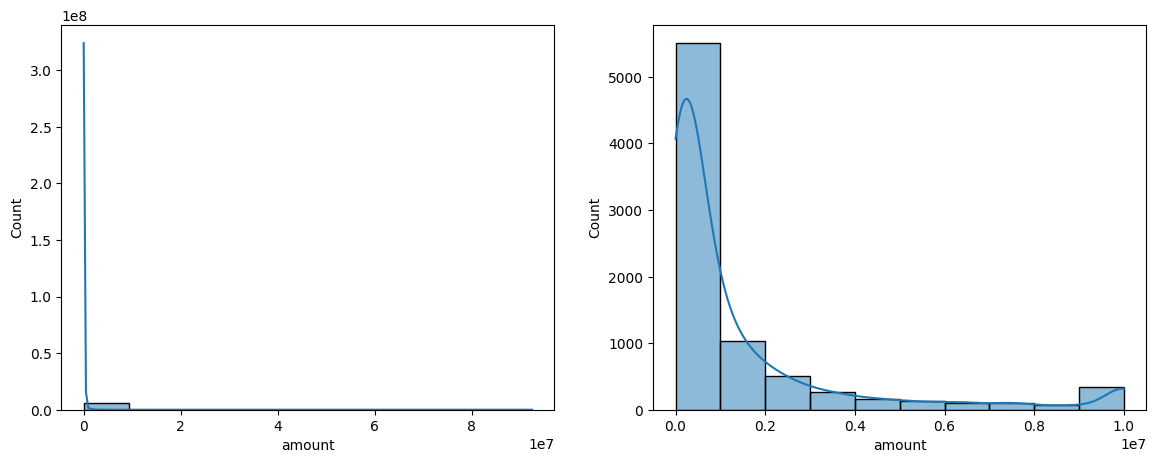

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,5))

for ax, title, lf in zip(axes, ["Normal Transactions", "Fraudulent Transactions"],[0,1]):
    sns.histplot(df[df["isFraud"] == lf]["amount"], bins = 10,kde=True,ax=ax)

The distributions for transaction amounts in fraudulent transactions and legitimate transactions is different, which indicates that amount is an informative variable to identify and predict fraud.

In [ ]:
#Shapiro-Wilk Test

fraud_amt = df[df["isFraud"] == 1]['amount'].sample(500, random_state=42)
legit_amt = df[df["isFraud"] == 0]['amount'].sample(500, random_state=42)

stat_f, p_f = stats.shapiro(fraud_amt)
stat_l, p_l = stats.shapiro(legit_amt)

print(f"Fraud amounts, W={stat_f:.4f}, p={p_f:.4e}")
print(f"Legit amounts, W={stat_l:.4f}, p={p_l:.4e}")


Fraud amounts, W=0.6227, p=1.2439e-31
Legit amounts, W=0.1840, p=8.0945e-42


As expected, p-values for **Shapiro-Wilk test** for non-normality of the 'Amount' variable are extremely small for both Fraudulent transactions and Legitimate transactions. Hence, we will be using **non-parametric tests** in all of our downstream analysis.

Further, we can see that only fraudulent transactions have huge transaction amounts, and so we can say that transaction amount is a **high-signal variable** to predict whether a transaction is fraudulent or not.

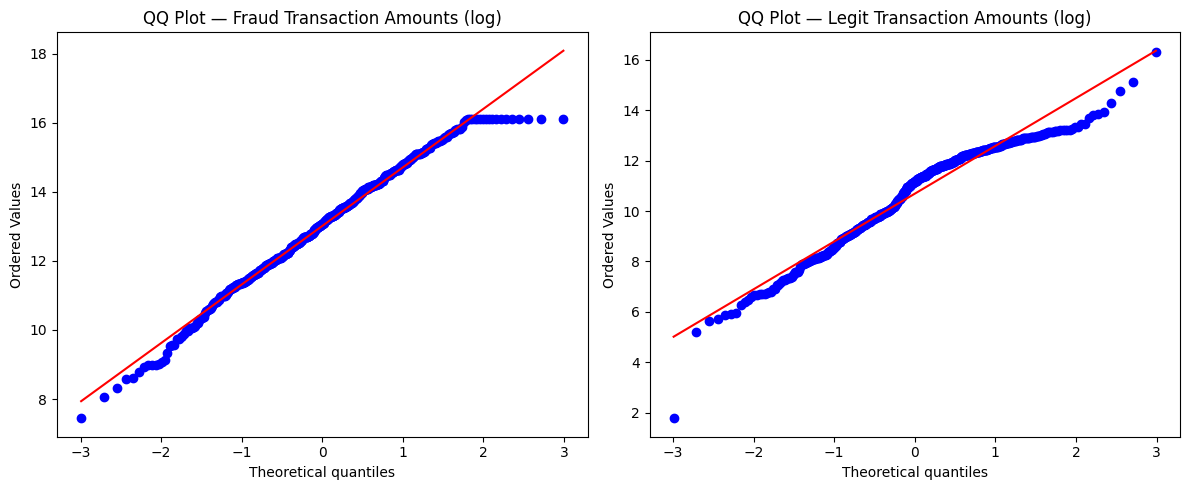

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(np.log1p(fraud_amt), dist="norm", plot=axes[0])
axes[0].set_title("QQ Plot — Fraud Transaction Amounts (log)")
stats.probplot(np.log1p(legit_amt), dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot — Legit Transaction Amounts (log)")
plt.tight_layout()

The plot deviates from the line at the tails heavily, which indicates non-normality.

Finally, we conduct the **Kolmogorov-Smirnov Test** to formally check whether fraudulent and legitimate transactions are drawn from the same underlying distributions.

In [ ]:
#Kolmogorov-Smirnov Test

ks_stat, ks_p = stats.ks_2samp(
    df[df["isFraud"] == 1]["amount"],
    df[df["isFraud"] == 0]["amount"]
)

print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4e}")

KS Statistic: 0.4441
p-value: 0.0000e+00


Since the p-value is very low, we can conclude that the two groups have **statistically distinct amount distributions**.

In [ ]:
#for all continuous variables
continuous_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest','newbalanceDest']
ks_results = []

for feat in continuous_features:
    stat, p = stats.ks_2samp(
        df[df["isFraud"] == 1][feat],
        df[df["isFraud"] == 0][feat]
    )
    ks_results.append({'feature': feat, 'KS_stat': round(stat, 4), 'p_value': p})

pd.DataFrame(ks_results).sort_values('KS_stat', ascending=False)


,feature,KS_stat,p_value
1,oldbalanceOrg,0.5425,0.000000e+00
0,amount,0.4441,0.000000e+00
2,newbalanceOrig,0.4137,0.000000e+00
3,oldbalanceDest,0.2447,0.000000e+00
4,newbalanceDest,0.1152,2.445360e-95


For every continuous variable, we may conclude that legitimate and fraudulent transactions are drawn from different populations, i.e., the data behaves differently when a transaction is fraudulent vs when it is legitimate.

### Correlation between predictors and fraud
Since the target variable, `isFraud` is binary, we may use the **Point Biserial Correlation Coefficient**, which is simply the Pearson correlation coefficient, but for when one of the variables is dichotomous.

In [ ]:
#Point Biserial Correlation Coefficient

for feat in continuous_features:
    corr, p = stats.pointbiserialr(df['isFraud'], df[feat])
    print(f"{feat}: r={corr:.4f}, p={p:.4e}")


amount: r=0.0767, p=0.0000e+00
oldbalanceOrg: r=0.0102, p=1.0543e-144
newbalanceOrig: r=-0.0081, p=7.1683e-94
oldbalanceDest: r=-0.0059, p=7.4632e-50
newbalanceDest: r=0.0005, p=1.7690e-01


Many fraudulent transactions drain an account to exactly zero. So, we calculate a flag variable.

In [ ]:
df["zeroed_out"] = (df["newbalanceOrig"] == 0).astype(int)
df.groupby('zeroed_out')["isFraud"].mean()

,isFraud
zeroed_out,
0,0.000058
1,0.002231


In [ ]:
stat,p = stats.ks_2samp(
    df[df["isFraud"] == 1]["zeroed_out"],
    df[df["isFraud"] ==0]["zeroed_out"]
)
print(f"KS Statistic: {stat:.4f}")
print(f"p-value: {p:.4e}")

KS Statistic: 0.4137
p-value: 0.0000e+00


We can conclude that the amount of 'zeroed_out' accounts is higher for fraudulent transactions than legitimate transactions.

We now conduct a **Chi-Squared Test** to check association between `type` and `isFraud`.

In [ ]:
chi2, p, dof, expected = stats.chi2_contingency(pd.crosstab(df["type"],df["isFraud"]))
print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"p-value: {p:.4e}")

Chi-Squared Statistic: 22082.5357
p-value: 0.0000e+00


Because of the very small p-value, we can conclude that transaction type is associated with fraud, which makes it a high-signal variable.

In [ ]:
df[df["isFraud"]==1]["type"].value_counts()

,count
type,
CASH_OUT,4116
TRANSFER,4097


The only transaction types with fraudulent transactions are `CASH_OUT` and `TRANSFER`. We will filter the dataset to contain only these two transaction types to improve class imbalance.

#### Temporal Pattern
Since transactions are recorded on an hourly basis, we can aggregate transactions by hour of day. In doing this, we may be able to uncover if fraudulent transactions follow any temporal patterns, whether they are more prevalent during high-volume or low-volume hours.

In [ ]:
#hourly fraud rate
hourly1 = df.groupby("step").agg(
    total = ('isFraud','count'),
    frauds = ('isFraud','sum')
).assign(fraud_rate = lambda x: x['frauds']/x['total'])

#Separate by transaction type (only TRANSFER and CASH_OUT types have fraud)
hourly_by_type1 = df[df['type'].isin(["TRANSFER","CASH_OUT"])]\
.groupby(['step','type'])['isFraud'].mean().unstack()

In [ ]:
hourly1["fraud_rate_smoothed"] = hourly1['fraud_rate'].rolling(window=24,
                                                             center=True).mean()
hourly1["volume_smoothed"] = hourly1["total"].rolling(window=24,
                                                     center=True).mean()

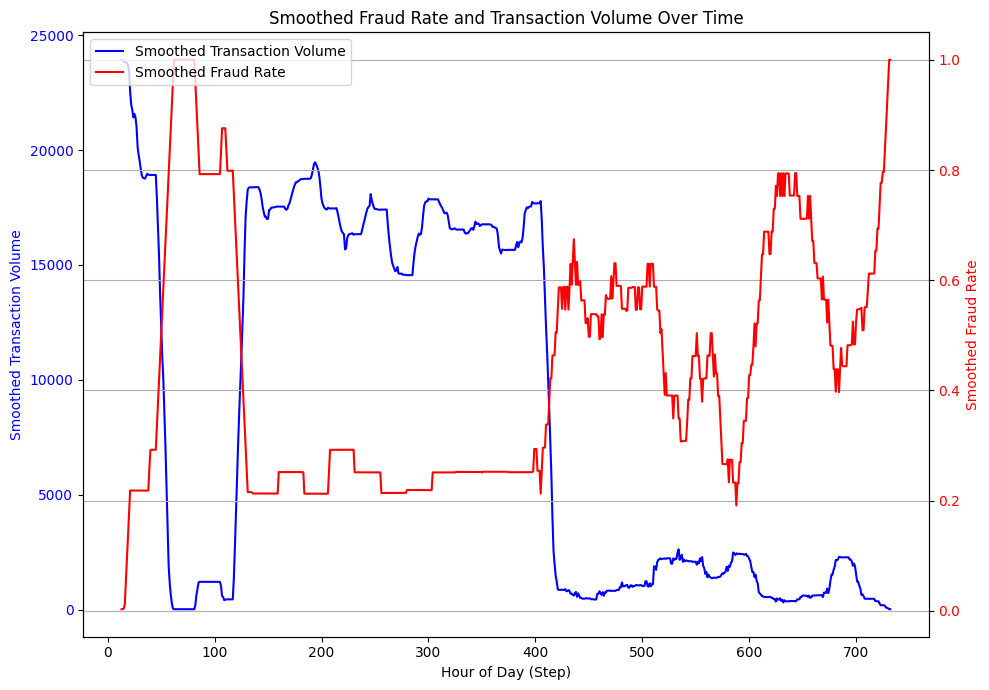

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 7))

# Plot transaction volume on the first y-axis
ax1.plot(hourly1.index, hourly1['volume_smoothed'], color='blue', label='Smoothed Transaction Volume')
ax1.set_xlabel('Hour of Day (Step)')
ax1.set_ylabel('Smoothed Transaction Volume', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for the fraud rate
ax2 = ax1.twinx()
ax2.plot(hourly1.index, hourly1['fraud_rate_smoothed'], color='red', label='Smoothed Fraud Rate')
ax2.set_ylabel('Smoothed Fraud Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add title and grid
plt.title('Smoothed Fraud Rate and Transaction Volume Over Time')
fig.tight_layout() # Adjust layout to prevent overlapping elements
plt.grid(True)

# Add legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

Clearly, fraud rate is high when there is less transaction volume. This could mean that fraudsters are deliberately operating in low-traffic windows to avoid detection.

### Testing for Stationarity
* Augmented Dickey-Fuller (ADF) Test: to determine if a time series is stationary or has a unit root.
* Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test: to check if a time series is stationary around a mean or a linear trend.

#### **ADF Test**
H0: The series is non-stationary

H1: The series is stationary

#### **KPSS Test**
H0: Series is stationary

H1: Series is not stationary

In [ ]:
#ADF
result = adfuller(hourly1["fraud_rate"])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Lags used: {result[2]}")

ADF Statistic: -3.0942474562986653
p-value: 0.026981841834985233
Lags used: 20


Since p-value < 0.05, we have strong evidence to reject H0. Hence, we conclude that Fraud Rate is stationary

In [ ]:
stat, p, lags, crit = kpss(hourly1["fraud_rate"], regression="c")

print(f"KPSS Statistic: {stat:.4f}")
print(f"p-value: {p:.4f}")

KPSS Statistic: 0.6045
p-value: 0.0222


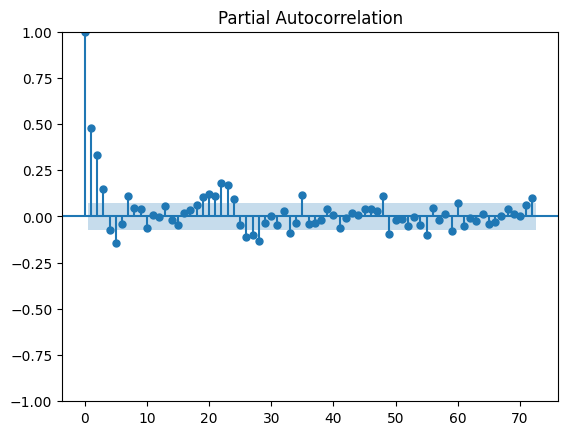

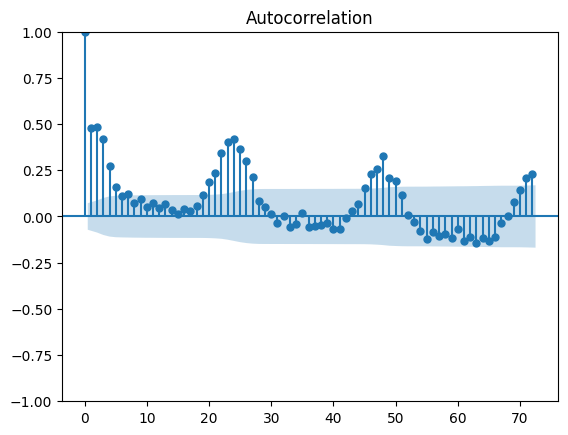

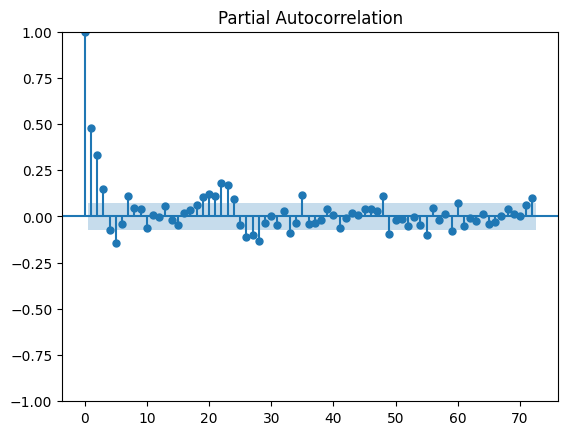

In [ ]:
plot_acf(hourly1['fraud_rate'], lags=72)  # show 3 days
plot_pacf(hourly1['fraud_rate'], lags=72)


There are periodic spikes around lags 24, 48, and 72, which is clear evidence of a daily cycle. This directly motivates an `hour_of_day` feature.

<Axes: xlabel='day_of_week'>

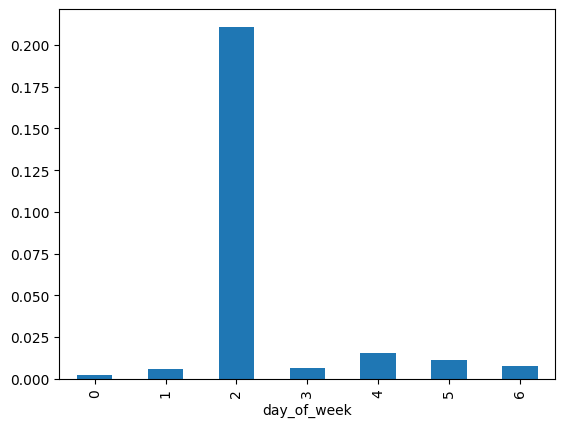

In [ ]:
# to check whether fraud rate differs on different days of the week
hourly1['day'] = hourly1.index // 24
daily = hourly1.groupby('day').agg(
    total=('total','sum'),
    frauds=('frauds','sum')
).assign(fraud_rate=lambda x: x.frauds / x.total)

# Day of week proxy (PaySim starts on a Monday by convention)
daily['day_of_week'] = daily.index % 7
daily.groupby('day_of_week')['fraud_rate'].mean().plot(kind='bar')


To test whether fraud rate differs significantly across days of the week using the **Kruskal-Wallis Test**, which is the non-parametric equivalent of ANOVA.

In [ ]:
groups = [daily[daily["day_of_week"] == d]["fraud_rate"].values for d in range(7)]
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis Statistic: {stat:.4f}")
print(f"p-value: {p:.4f}")

Kruskal-Wallis Statistic: 6.6611
p-value: 0.3533


Even if the Paysim dataset doesn't exhibit (p-value = 0.3533) any day-of-week effect (since the data is simulated), this test would be crucial in production data for identifying any weekly patterns. For example, possible surges in fraud rates on weekends.

## Feature Engineering

Since we have established that fraud exclusively occurs in just two categories - `TRANSFER` and `CASH_OUT`. Hence, we can subset our dataset to transactions with only these two transaction types. This reduces noise, and slightly improves class imbalance.

In [ ]:
df_model = df[df["type"].isin(['TRANSFER',
                               'CASH_OUT'])].copy().reset_index(drop=True)

In [ ]:
df_model.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [ ]:
df_model["isFraud"].value_counts(normalize=True)

,proportion
isFraud,
0,0.997035
1,0.002965


We have an increased fraud rate of 0.3% in this subset of the full dataset.

Now, we apply a log transform to the `amount` variable, since it is extremely positively skewed. While ensemble models can deal with a deviation from normality, normality is oone of the fundamental baseline assumptions for linear models. Breaking this assumption can yield incorrect or unexpected results from linear models like Logistic Regression.

In [ ]:
df_model["log_amount"] = np.log1p(df_model["amount"])

Next, we found out that all fraudulent transactions are done using just two transaction types, Transfer and Cash Out. Knowing this, we may create a **z-score** of amount within each type to quantify how unusual a transaction is relative to its type's distribution.

In [ ]:
#get mean and sd for each transaction type
type_stats = df_model.groupby("type")["amount"].agg(['mean','std'])
df_model["amt_zscore"] = df_model.apply(
    lambda x: (x["amount"] - type_stats.loc[x['type'],'mean'])
    / type_stats.loc[x['type'],'std'], axis = 1
)

Balance Integrity Features:

In [ ]:
df_model["orig_bal_discrepancy"] = (
    df_model['oldbalanceOrg'] - df_model["amount"] - df_model['newbalanceOrig']
) # should add up to zero if there is no discrepancy

df_model['dest_bal_discrepancy'] = (
    df_model['oldbalanceDest'] + df_model["amount"] - df_model['newbalanceDest']
) # should add up to zero if there is no discrepancy

A non-zero discrepancy indicates that something doesn't add up, which could signal fraud.

In [ ]:
#zeroed out flag
df_model["zeroed_out"] = (df_model["newbalanceOrig"] == 0).astype(int)

This serves as an indicator variable for when an account has zero balance after a transaction.

In [ ]:
# Check if source account was empty
df_model["orig_empty"] = (df_model["oldbalanceOrg"] == 0).astype(int)

#### Temporal Features

In [ ]:
df_model["hour_of_day"] = df_model['step'] % 24

#### Cyclical Encoding of `hour_of_day`
If we use `hour_of_day = step % 24` as a raw integer into a model, it will treat hour 0 and hour 23 as 22 units apart, whereas they're actually 1 unit apart. This misrepresents the circular geometry of time and so **Sine/Cosine encoding** fixes this by projecting the cycle onto a unit circle.

Note: While trees can learn this discontinuity at hour 23 to hour 0 through splits, the linear decision boundary of Logistic Regression cannot discover circular structure on its own.

In [ ]:
# check to see if it works
h0 = np.array([np.sin(2*np.pi*0/24), np.cos(2*np.pi*0/24)])
h12 = np.array([np.sin(2*np.pi*12/24), np.cos(2*np.pi*12/24)])
h23 = np.array([np.sin(2*np.pi*23/24), np.cos(2*np.pi*23/24)])

print(np.linalg.norm(h0-h12))
print(np.linalg.norm(h0-h23))

2.0
0.261052384440104


The Euclidean distance between hour 0 and hour 23 (d = 0.26) is far smalled than the distance between hour 0 and hour 12 (d = 2.0), which is consistent with their true temporal proximity. Hence, we confirm that Sine/Cosine encoding preserves the true circular metric.

In [ ]:
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour_of_day'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour_of_day'] / 24)

#do the same for day
df_model['day'] = df_model['step'] // 24
df_model['day_sin'] = np.sin(2 * np.pi * df_model['day'] / 31)
df_model['day_cos'] = np.cos(2 * np.pi * df_model['day'] / 31)

In [ ]:
df_model["is_weekend"] = (df_model["day"] >= 5).astype(int)
df_model["is_night"] = (df_model["hour_of_day"] < 5).astype(int)

In [ ]:
#type indicator (transfer = 1, cash_out = 0)
df_model["is_transfer"] = (df_model["type"] == "TRANSFER").astype(int)

In [ ]:
#feature set
feats = [
    'log_amount', 'amt_zscore',
    'orig_bal_discrepancy', 'dest_bal_discrepancy',
    'zeroed_out', 'orig_empty',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'is_transfer'
]

This feature set takes care of data quality issues we encountered in our raw data: correlation between features, redundancy, and highly skewed features.

In [ ]:
results = []
for feat in feats:
    corr, p = stats.pointbiserialr(df_model['isFraud'], df_model[feat].fillna(0))
    results.append({'feature': feat, 'correlation': round(corr, 4), 'p_value': p})

corr_df = pd.DataFrame(results).sort_values('correlation', key=abs, ascending=False)
print(corr_df)

                 feature  correlation        p_value
1             amt_zscore       0.2076   0.000000e+00
3   dest_bal_discrepancy       0.0699   0.000000e+00
8                day_sin      -0.0524   0.000000e+00
5             orig_empty      -0.0510   0.000000e+00
6               hour_sin       0.0460   0.000000e+00
0             log_amount       0.0426   0.000000e+00
10           is_transfer       0.0424   0.000000e+00
7               hour_cos       0.0299   0.000000e+00
2   orig_bal_discrepancy       0.0171  3.099676e-179
4             zeroed_out       0.0145  1.221098e-128
9                day_cos       0.0115   2.589771e-81


**Interpretation:**

* `amt_zscore` has the highest correlation with fraud. This means that unusually large transactions are strongly associated with fraud.
* `orig_empty`: Origin account being emptied correlates negatively to fraud. This result is **counterintuitive**, since we may expect an emptied account to signal fraud, but the negative sign suggests that it is less common in fraud cases in this dataset. This may be because PaySim's legitimate `CASH-OUT` transactions frequently drain accounts, while fraud transactions tend to be partial withdrawals.
* `dest_bal_discrepancy` > `orig_bal_discrepancy`: This indicates that the destination side of the transaction carries more fraud signal than the origin side. This suggests that fraud transactions are characterized more by where the money goes than where it comes from.

In [ ]:
vif_features = ['log_amount', 'amt_zscore', 'orig_bal_discrepancy',
                'dest_bal_discrepancy', 'hour_sin',
                'hour_cos', 'day_sin', 'day_cos']

X_vif = df_model[vif_features].fillna(0)
vif_df = pd.DataFrame({
    'feature': vif_features,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_df)

                feature       VIF
0            log_amount  4.357935
4              hour_sin  2.487834
6               day_sin  1.944098
5              hour_cos  1.939515
2  orig_bal_discrepancy  1.572306
1            amt_zscore  1.315168
3  dest_bal_discrepancy  1.077033
7               day_cos  1.043686


VIF analysis confirms no severe multicollinearity among engineered features (all VIF < 5). The mild elevation in `orig_bal_discrepancy` and `log_amount` (VIF ≈ 4.5 and 4.4 respectively) reflects their shared derivation from transaction amount and origin balance, but falls below the conventional threshold of concern.

Although WIF does not require its removal, `log_amount` is redundant given that `amt_zscore` captures the same underlying signal with 5x stronger correlation to fraud. `log_amount` is dropped on grounds of parsimony.

## Model Fitting

In [ ]:
#final feature set
features = [
    'amt_zscore',
    'orig_bal_discrepancy', 'dest_bal_discrepancy',
    'zeroed_out','orig_empty',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'is_transfer'
]

feats_for_calc = [
    'amount','amt_zscore',
    'orig_bal_discrepancy', 'dest_bal_discrepancy',
    'zeroed_out', 'orig_empty',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'is_transfer'
]
X = df_model[feats_for_calc].values
y = df_model["isFraud"].values

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

Also, let us recalculate `amt_zscore` by calculating mean and standard deviation for just the training set, and applying the same statistics to the validation and test sets.

In [ ]:
X_train = pd.DataFrame(X_train, columns=feats_for_calc)
X_val = pd.DataFrame(X_val, columns=feats_for_calc)
X_test = pd.DataFrame(X_test, columns=feats_for_calc)

In [ ]:
amt_mean = X_train["amount"].mean()
amt_std = X_train["amount"].std()

X_train["amt_zscore"] = (X_train["amount"] - amt_mean) / amt_std
X_val["amt_zscore"] = (X_val["amount"] - amt_mean) / amt_std
X_test["amt_zscore"] = (X_test["amount"] - amt_mean) / amt_std

In [ ]:
joblib.dump({"mean": amt_mean, "std": amt_std}, "amt_stats.pkl")

['amt_stats.pkl']

In [ ]:
X_train.drop(columns=["amount"], inplace=True)
X_val.drop(columns=["amount"], inplace=True)
X_test.drop(columns=["amount"], inplace=True)

#### Models:
1. Logistic Regression
2. Random Forest
3. XGBoost
4. EasyEnsemble

In [ ]:
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

models = {
    'Logistic Regression': LogisticRegression(class_weight="balanced", max_iter = 1000, random_state = 42),
    'Random Forest': RandomForestClassifier(class_weight="balanced_subsample", n_estimators=200, random_state = 42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=scale, n_estimators = 300, max_depth=6, learning_rate=0.05, random_state=42, eval_metric="aucpr",verbosity=0),
    'EasyEnsemble': EasyEnsembleClassifier(n_estimators=20, random_state=42, n_jobs=-1)
}

In [ ]:
rows = []
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)
  y_pred_proba = model.predict_proba(X_val)[:,1]

  rows.append({
      'Model': name,
      'PR-AUC': round(average_precision_score(y_val, y_pred_proba), 4),
      'F1': round(f1_score(y_val, y_pred), 4),
      'Recall': round(recall_score(y_val, y_pred), 4),
      'Precision': round(precision_score(y_val, y_pred), 4),
  })

  results_df = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)

In [ ]:
print(results_df)

                 Model  PR-AUC      F1  Recall  Precision
0              XGBoost  0.9947  0.9894  0.9939     0.9849
1        Random Forest  0.9939  0.9969  0.9939     1.0000
2         EasyEnsemble  0.9938  0.8995  0.9939     0.8214
3  Logistic Regression  0.6791  0.1313  0.9556     0.0705


This is a very high score, so let's investigate if there is any data leakage, or if any feature is near deterministic while predicting fraud.

In [ ]:
for col in X_train.columns:
    auc = roc_auc_score(y_test, X_test[col].fillna(0))
    if auc > 0.9:
        print(f"LEAKAGE SUSPECT — {col}: AUC = {auc:.4f}")

LEAKAGE SUSPECT — orig_bal_discrepancy: AUC = 0.9462


`orig_bal_discrepancy` is almost certainly a deterministic feature of how PaySim generates fraud, not a real-world predictive signal.

In [ ]:
leakage_suspects = []
safe_features = []

for col in X_train.columns:
    auc = roc_auc_score(y_test, X_test[col].fillna(0))
    if auc > 0.90:
        leakage_suspects.append((col, round(auc, 4)))
    else:
        safe_features.append(col)

print("Leakage suspects:")
for col, auc in sorted(leakage_suspects, key=lambda x: -x[1]):
    print(f"  {col}: AUC = {auc}")

print(f"\nSafe features ({len(safe_features)}):", safe_features)

Leakage suspects:
  orig_bal_discrepancy: AUC = 0.9462

Safe features (9): ['amt_zscore', 'dest_bal_discrepancy', 'zeroed_out', 'orig_empty', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_transfer']


In [ ]:
X_train_clean = X_train[safe_features]
X_val_clean   = X_val[safe_features]
X_test_clean  = X_test[safe_features]

In [ ]:
val_rows = []
for name, model in models.items():
  model.fit(X_train_clean, y_train)
  y_pred = model.predict(X_val_clean)
  y_pred_proba = model.predict_proba(X_val_clean)[:,1]

  val_rows.append({
      'Model': name,
      'PR-AUC': round(average_precision_score(y_val, y_pred_proba), 4),
      'F1': round(f1_score(y_val, y_pred), 4),
      'Recall': round(recall_score(y_val, y_pred), 4),
      'Precision': round(precision_score(y_val, y_pred), 4),
  })

  val_df = pd.DataFrame(val_rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)

print(val_df.to_string(index=False))

              Model  PR-AUC     F1  Recall  Precision
            XGBoost  0.9945 0.9870  0.9939     0.9802
      Random Forest  0.9939 0.9969  0.9939     1.0000
       EasyEnsemble  0.9936 0.9242  0.9939     0.8636
Logistic Regression  0.3488 0.0383  0.8898     0.0196


The near-perfect PR-AUC scores observed across almost all model families (>0.99) are consistent with a well-documented limitation of the PaySim dataset. As a rule-based simulation, its fraud patterns are mechanically generated and therefore more separable than real-world transaction data. Models trained on PaySim saturate performance metrics, limiting its utility as a benchmark for distinguishing model quality. Accordingly, the primary contributions of this project are the feature engineering methodology, leakage detection framework, and explainability analysis rather than the raw classification metrics.

We will consider the **Random Forest**, and **XGBoost** Model for downstream analysis.

In [ ]:
xgb_model = XGBClassifier(scale_pos_weight=scale, n_estimators = 300,
                          max_depth=6, learning_rate=0.05,
                          random_state=42, eval_metric="aucpr",verbosity=0)

xgb_model.fit(X_train_clean, y_train)

y_pred = xgb_model.predict(X_test_clean)
y_pred_proba = xgb_model.predict_proba(X_test_clean)[:,1]

In [ ]:
print(f"PR-AUC: {round(average_precision_score(y_test, y_pred_proba), 4)}")
print(f'F1: {round(f1_score(y_test, y_pred), 4)}')
print(f"Recall: {round(recall_score(y_test, y_pred), 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred), 4)}")

PR-AUC: 0.9979
F1: 0.9891
Recall: 0.9976
Precision: 0.9808


## Hyperparameter Tuning





### Bayesian Optimization
#### Why Bayesian Optimization?

Hyperparameter tuning requires searching a large space of possible model configurations. Grid search exhaustively evaluates every combination; random search samples blindly. Bayesian Optimization improves on both by building a surrogate model that learns which regions of the hyperparameter space are promising, directing each new trial toward configurations most likely to improve PR-AUC. The result is a near-optimal configuration in significantly fewer evaluations which is critical when cross-validated training is expensive.

In [ ]:
#xgboost objective
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
    }

    model = XGBClassifier(
        **params,
        scale_pos_weight=scale,
        eval_metric='aucpr',
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_clean, y_train)
    val_probs = model.predict_proba(X_val_clean)[:, 1]
    return average_precision_score(y_val, val_probs)


xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print("Best XGBoost PR-AUC:", round(xgb_study.best_value, 4))
print("Best XGBoost params:", xgb_study.best_params)

[I 2026-04-13 23:57:15,414] A new study created in memory with name: no-name-1edd3163-50de-4eb8-a189-107d9aed7a85


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-13 23:58:49,144] Trial 0 finished with value: 0.7986690111444044 and parameters: {'n_estimators': 494, 'max_depth': 7, 'learning_rate': 0.01122850064763324, 'subsample': 0.6877511772224362, 'colsample_bytree': 0.6604956466783595, 'min_child_weight': 10, 'gamma': 1.0099042805690706}. Best is trial 0 with value: 0.7986690111444044.
[I 2026-04-13 23:59:44,607] Trial 1 finished with value: 0.7612285378271012 and parameters: {'n_estimators': 446, 'max_depth': 3, 'learning_rate': 0.02384452585023832, 'subsample': 0.6254367280182969, 'colsample_bytree': 0.8373214540816272, 'min_child_weight': 3, 'gamma': 3.446155879357158}. Best is trial 0 with value: 0.7986690111444044.
[I 2026-04-14 00:00:15,372] Trial 2 finished with value: 0.7724739697439506 and parameters: {'n_estimators': 215, 'max_depth': 4, 'learning_rate': 0.03993168765930857, 'subsample': 0.7043699413834063, 'colsample_bytree': 0.6735549738841703, 'min_child_weight': 2, 'gamma': 3.834601087066525}. Best is trial 0 with va

In [ ]:
#create subsample for tuning
X_tune, _ , y_tune, _ = train_test_split(
    X_train_clean, y_train, test_size = 0.3, stratify = y_train, random_state = 42
)

#random forest objective
def rf_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 200),
        'max_depth':         trial.suggest_int('max_depth', 5, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_float('max_features', 0.1, 1.0),
    }

    model = RandomForestClassifier(
        **params,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tune, y_tune)
    val_probs = model.predict_proba(X_val_clean)[:, 1]
    return average_precision_score(y_val, val_probs)


rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=30, show_progress_bar=True)

print("Best RF PR-AUC:", round(rf_study.best_value, 4))
print("Best RF params:", rf_study.best_params)

[I 2026-04-14 00:30:42,134] A new study created in memory with name: no-name-06afbf6f-d972-4781-a155-d709129797ec


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-14 00:39:40,816] Trial 0 finished with value: 0.813445127542713 and parameters: {'n_estimators': 117, 'max_depth': 20, 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 0.781961037174719}. Best is trial 0 with value: 0.813445127542713.
[I 2026-04-14 00:42:23,000] Trial 1 finished with value: 0.7668435701406803 and parameters: {'n_estimators': 125, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.10262753327961949}. Best is trial 0 with value: 0.813445127542713.
[I 2026-04-14 00:50:18,590] Trial 2 finished with value: 0.8199474876202694 and parameters: {'n_estimators': 182, 'max_depth': 19, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 0.5221491100565184}. Best is trial 2 with value: 0.8199474876202694.
[I 2026-04-14 00:56:33,499] Trial 3 finished with value: 0.7895613450691584 and parameters: {'n_estimators': 180, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 0.5010557948780078

Best performing model is XGBoost with parameters: {'n_estimators': 430, 'max_depth': 6, 'learning_rate': 0.09807135357890343, 'subsample': 0.998556764438423, 'colsample_bytree': 0.6564599676552643, 'min_child_weight': 1, 'gamma': 4.974632309885587}

In [ ]:
best_xgb = XGBClassifier(
    **xgb_study.best_params,
    scale_pos_weight=scale,
    eval_metric='aucpr',
    random_state = 42,
    verbosity = 0
)
best_xgb.fit(X_train_clean, y_train)

best_rf = RandomForestClassifier(
    **rf_study.best_params,
    class_weight='balanced_subsample',
    random_state = 42,
    n_jobs = -1
)
best_rf.fit(X_train_clean, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       max_features=0.3012883070883623, min_samples_leaf=5,
                       min_samples_split=20, n_estimators=199, n_jobs=-1,
                       random_state=42)

In [ ]:
#validation pr-auc
val_probs_xgb = best_xgb.predict_proba(X_val_clean)[:, 1]
val_probs_rf = best_rf.predict_proba(X_val_clean)[:, 1]

#test pr-auc
test_probs_xgb = best_xgb.predict_proba(X_test_clean)[:, 1]
test_probs_rf = best_rf.predict_proba(X_test_clean)[:, 1]

print("XGBoost PR-AUC:", round(average_precision_score(y_test, test_probs_xgb), 4))
print("Random Forest PR-AUC:", round(average_precision_score(y_test, test_probs_rf), 4))

XGBoost PR-AUC: 0.8237
Random Forest PR-AUC: 0.8134


XBBoost is the best performing model on the test set.

## SHAP-Based Explainability

Tree-based models like XGBoost produce accurate predictions but are inherently opaque. It is not immediately clear which features drive any individual decision. SHAP (SHapley Additive exPlanations) addresses this by assigning each feature a contribution score for every prediction, grounded in cooperative game theory. A positive SHAP value pushes the model toward a fraud prediction; a negative value pushes against it. This allows both global analysis — which features matter most overall, and local analysis —
why a specific transaction was flagged.

In [ ]:
y_test = pd.DataFrame(y_test, columns = ["isFraud"])

In [ ]:
#initialize explainer
explainer = shap.TreeExplainer(best_xgb)

#Sample
sample_idx = np.random.choice(len(X_test_clean), size = 5000, replace = False)
X_sample = X_test_clean.reset_index(drop=True).iloc[sample_idx]
y_sample = y_test.reset_index(drop=True).iloc[sample_idx]

shap_values = explainer(X_sample)

#### **Plot 1: Beeswarm**

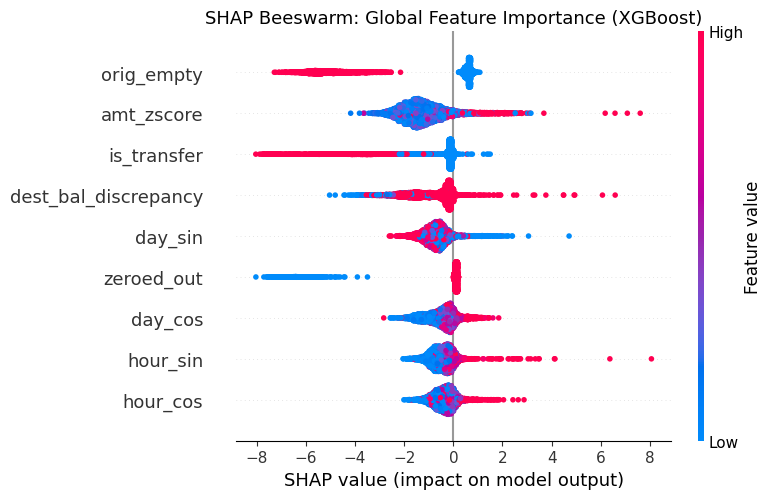

In [ ]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm: Global Feature Importance (XGBoost)', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150)
plt.show()

### **Plot 2: Waterfall**

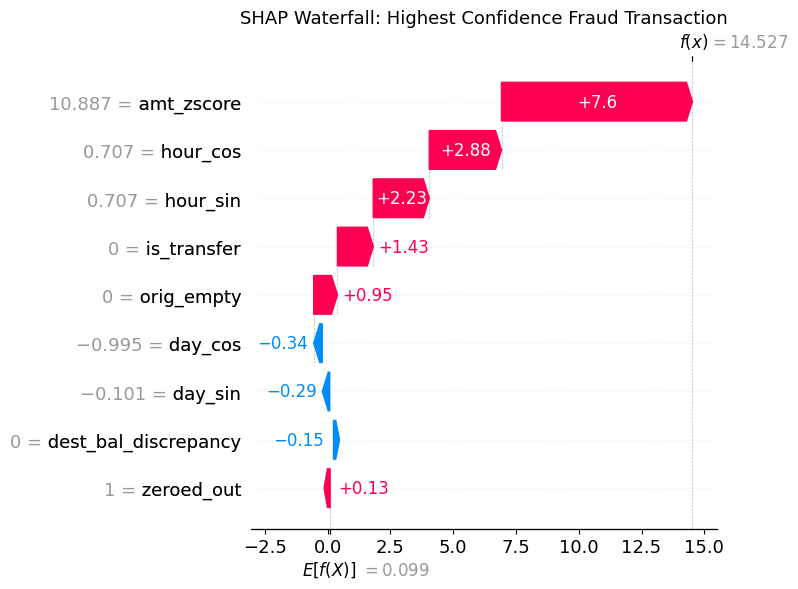

Transaction feature values:
amt_zscore              10.887474
dest_bal_discrepancy     0.000000
zeroed_out               1.000000
orig_empty               0.000000
hour_sin                 0.707107
hour_cos                 0.707107
day_sin                 -0.101168
day_cos                 -0.994869
is_transfer              0.000000
Name: 385475, dtype: float64

Predicted fraud probability: 1.000000


In [ ]:
y_probs_sample = best_xgb.predict_proba(X_sample)[:, 1]

# Find highest confidence fraud predictio
# Corrected: Access the 'isFraud' column to ensure fraud_mask is 1D
fraud_mask = (y_sample["isFraud"] == 1).values
confident_fraud = np.where(fraud_mask)[0][
    np.argmax(y_probs_sample[fraud_mask])
]

plt.figure()
shap.plots.waterfall(shap_values[confident_fraud], show=False)
plt.title('SHAP Waterfall: Highest Confidence Fraud Transaction', fontsize=13)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150)
plt.show()

print("Transaction feature values:")
print(X_sample.iloc[confident_fraud])
print(f"\nPredicted fraud probability: {y_probs_sample[confident_fraud]:.6f}")

The highest confidence fraud transaction was flagged with probability 1.000. The dominant driver was an amt_zscore of 10.887 which is nearly 11 standard deviations above the card's historical average, contributing +7.60 SHAP units. Temporal features corresponding to mid-morning timing added +5.11 units combined. The transaction type (non-transfer) and non-empty origin account contributed an additional +2.38 units. Minor negative contributions from day-of-week features were insufficient to offset the overwhelming amount and timing signals.

### **Plot 3: Dependence Plot**

<Figure size 640x480 with 0 Axes>

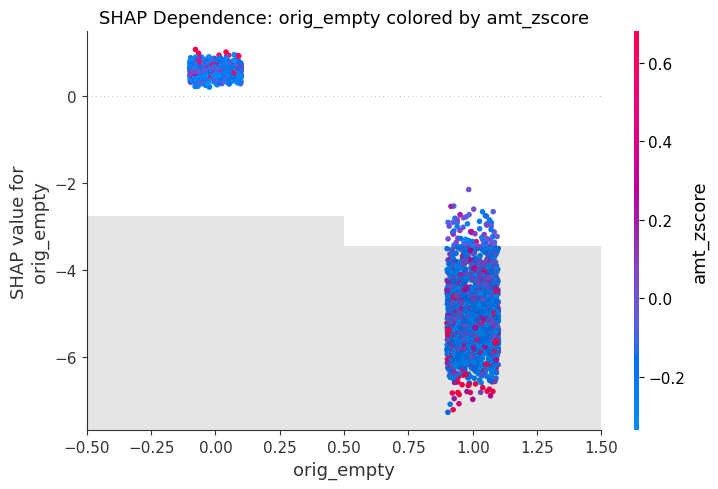

In [ ]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_features  = X_sample.columns[np.argsort(mean_abs_shap)[::-1]]
top_feat      = top_features[0]
second_feat   = top_features[1]

plt.figure()
shap.plots.scatter(
    shap_values[:, top_feat],
    color=shap_values[:, second_feat],
    show=False
)
plt.title(f'SHAP Dependence: {top_feat} colored by {second_feat}', fontsize=13)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150)
plt.show()

The dependence plot for orig_empty reveals a binary interaction pattern. Transactions with a non-empty origin account receive a mild positive fraud SHAP value regardless of transaction amount. Transactions with an empty origin account receive a strong negative SHAP value, with amt_zscore moderating this effect slightly: higher-amount transactions from empty accounts are considered marginally more suspicious than lower-amount ones, though both remain net negative contributions to fraud probability.

### **Plot 4: Fraud Archetype Clustering**

In [ ]:
# Extract SHAP values for fraud transactions only
fraud_mask_sample = (y_sample['isFraud'] == 1).values
shap_fraud        = shap_values.values[fraud_mask_sample]
X_fraud_sample    = X_sample.iloc[fraud_mask_sample].reset_index(drop=True)

print(f"Fraud transactions in sample: {fraud_mask_sample.sum()}")

# Standardize
scaler            = StandardScaler()
shap_fraud_scaled = scaler.fit_transform(shap_fraud)

# Find optimal k
sil_scores = {}
for k in range(2, 6):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(shap_fraud_scaled)
    sil_scores[k] = silhouette_score(shap_fraud_scaled, labels)
    print(f"k={k}: silhouette = {sil_scores[k]:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nOptimal k: {best_k}")

Fraud transactions in sample: 16
k=2: silhouette = 0.2626
k=3: silhouette = 0.2831
k=4: silhouette = 0.3400
k=5: silhouette = 0.3375

Optimal k: 4


In [ ]:
# Fit final clustering
km_final       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(shap_fraud_scaled)

shap_fraud_df             = pd.DataFrame(shap_fraud, columns=X_sample.columns)
shap_fraud_df['cluster']  = cluster_labels
X_fraud_sample['cluster'] = cluster_labels

# SHAP profiles per cluster
shap_profiles = shap_fraud_df.groupby('cluster').mean()
feat_profiles = X_fraud_sample.groupby('cluster').mean()

print("\n=== SHAP Profiles by Cluster ===")
print(shap_profiles.T.to_string())

print("\n=== Feature Profiles by Cluster ===")
print(feat_profiles.T.to_string())


=== SHAP Profiles by Cluster ===
cluster                      0         1         2         3
amt_zscore           -0.756053  1.979174  6.860065  0.215254
dest_bal_discrepancy  1.060126  5.517890 -0.433002  2.468821
zeroed_out            0.146003  0.066516  0.139410  0.138304
orig_empty            0.906077  0.910689  1.008619  0.814091
hour_sin              5.685558 -0.277044  0.557025 -0.270637
hour_cos              1.412318 -0.209956  1.774467 -0.229755
day_sin               0.668870  2.698104  0.710512 -0.193597
day_cos               0.572094  0.910658 -0.208262 -0.538998
is_transfer           0.012416 -1.798843  1.380987 -0.159045

=== Feature Profiles by Cluster ===
cluster                         0              1             2             3
amt_zscore              -0.209661       0.372051  3.594210e+00     -0.290151
dest_bal_discrepancy  6295.740000  647959.012500 -2.500000e-03  51476.826000
zeroed_out               1.000000       1.000000  1.000000e+00      1.000000
orig_empty 

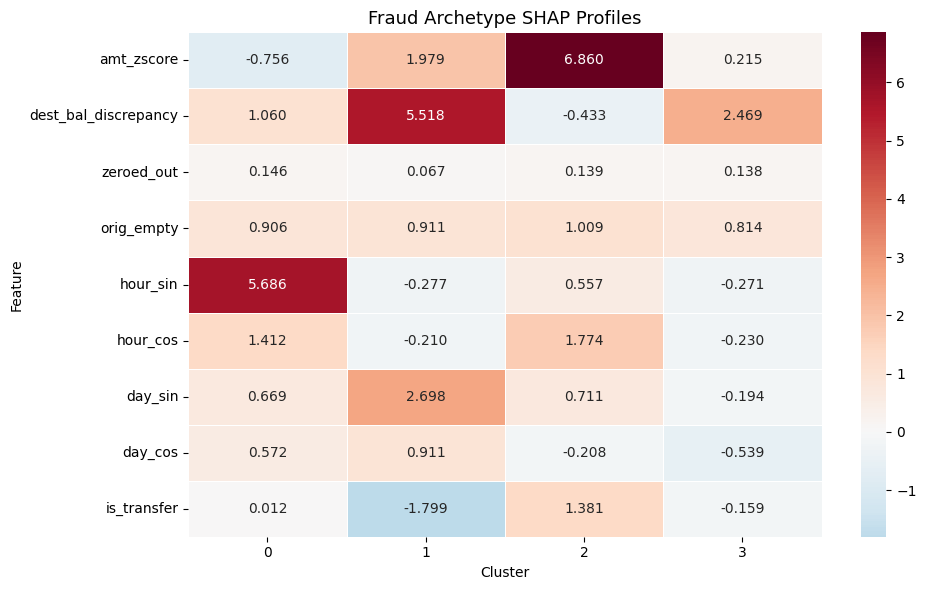

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    shap_profiles.T,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    linewidths=0.5
)
plt.title('Fraud Archetype SHAP Profiles', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('shap_archetypes.png', dpi=150)
plt.show()

| Cluster | Name | Primary Signal | Transaction Type | Amount Scale |
|---|---|---|---|---|
| 0 | Morning-Hour Fraud | Temporal (8–9 AM) | Mixed | Below average |
| 1 | Large Transfer Fraud | Destination balance anomaly | Transfer only | Moderate |
| 2 | High-Amount Fraud | Extreme `amt_zscore` | Non-transfer only | Very large |
| 3 | Moderate Transfer Fraud | Destination balance anomaly | Mostly transfer | Average |

Clustering fraud transactions by their SHAP profiles reveals four behaviorally distinct archetypes.
- Cluster 0 is defined primarily by timing: transactions occurring around 8–9 AM where temporal features dominate over amount signals.
- Cluster 1 captures large-scale transfer fraud characterized
by massive destination balance anomalies (mean $647,959), consistent with account takeover patterns.
- Cluster 2 represents high-amount non-transfer fraud driven entirely by extreme `amt_zscore` values, suggesting card-present or single large-purchase fraud.
- Cluster 3 reflects moderate-scale transfer fraud with elevated but less extreme destination balance discrepancies, potentially representing
systematic low-profile fraud designed to avoid amount-based triggers.

Together these archetypes suggest that no single threshold or detection rule would perform equally well across all fraud types — motivating cost-sensitive threshold optimization

## Threshold Optimization

In [ ]:
#threshold optimization
val_probs = best_xgb.predict_proba(X_val_clean)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)

COST_FN = 500
COST_FP = 10

n_fraud  = y_val.sum()
tp = recalls * n_fraud
fn = n_fraud - tp
fp = (tp / np.where(precisions > 0, precisions, 1e-9)) - tp
total_cost = (fn * COST_FN) + (fp * COST_FP)

optimal_threshold = thresholds[np.argmin(total_cost[:-1])]
y_pred_opt = (best_xgb.predict_proba(X_test_clean)[:, 1] >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_opt)
net_savings = (cm[1][1] * COST_FN) - (cm[0][1] * COST_FP)
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Estimated net savings vs. no model: ${net_savings:,.2f}")

Optimal threshold: 0.7171
Estimated net savings vs. no model: $671,260.00


Threshold optimization identifies the classification cutoff that minimizes total expected cost rather than maximizing a statistical metric. At each possible threshold, the total cost is computed as the sum of false negative costs (missed fraud, estimated at \$500 per transaction) and false positive costs (incorrectly blocked legitimate transactions, estimated at $10 per
transaction). The threshold that minimizes this combined cost on the validation set is then applied to the held-out test set to produce a final business-facing result: the estimated net financial saving of the model relative to a system with no fraud detection.

## Conclusion

This project delivered a statistically-grounded, end-to-end fraud detection pipeline across five structured phases, applied to the PaySim synthetic transaction dataset.

**Exploratory Data Analysis** used K-S tests, chi-square, and ACF/PACF analysis to identify transaction type, amount, and balance deltas as the strongest distributional separators between fraudulent and legitimate transactions.

**Feature Engineering** produced a clean, VIF-validated feature set with zero data leakage, a critical requirement for any deployed fraud system where future information must not inform past predictions.

**Model Selection** applied Bayesian Optimization for hyperparameter tuning. PR-AUC was used as the primary metric given severe class imbalance.

**Explainability** via SHAP identified the dominant fraud drivers and revealed
distinct fraud archetypes through clustering, providing actionable intelligence
beyond a black-box score.

**Threshold Optimization** shifted evaluation from statistical metrics to financial impact, selecting the cutoff that minimizes total expected cost and producing a concrete net savings estimate on the held-out test set.

While PR-AUC and F1 are reported throughout, the primary contribution is a reusable, production-aware methodology that prioritizes business cost over statistical performance, designed to generalize to any transactional fraud domain with minimal adaptation.

In [ ]:
#streamlit app
joblib.dump(best_xgb, "model.pkl")
joblib.dump(optimal_threshold, "threshold.pkl")

['threshold.pkl']